<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [37]:
# Check for GPU
!nvidia-smi

Sun Apr 13 13:58:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             30W /   70W |     166MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [40]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

2.6.0+cu124


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

In [39]:
medical imaging,autonomous vehicles, robotics

SyntaxError: invalid syntax (<ipython-input-39-6893d1e1a028>, line 1)

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [ ]:
overfitting in a model means making a model which can only perform operations on the data it was trained on.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [ ]:
1. train with more data
2. feature selection
3. regularization

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [41]:
import torch
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor

train_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform = None
)
test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [42]:
len(train_data),len(test_data)

(60000, 10000)

In [43]:
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [44]:

class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

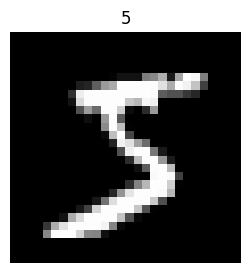

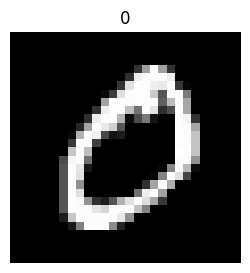

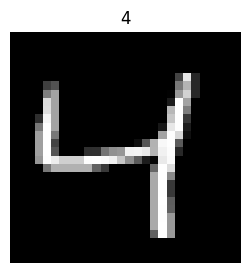

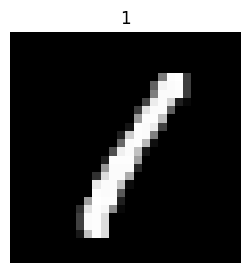

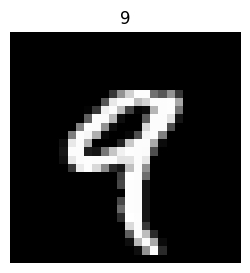

In [45]:
import matplotlib.pyplot as plt
for i in range(5):
  img =train_data[i][0]
  label =train_data[i][1]
  plt.figure(figsize=(3,3))
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(label)
  plt.axis(False)


## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [46]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x782105b71ad0>,
 <torch.utils.data.dataloader.DataLoader at 0x782105b3a550>)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [47]:
## creating model
from torch import nn
class CNNModel(nn.Module):
  def __init__(self,input_channel:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels=input_channel,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier =nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )
  def forward(self,x:torch.tensor):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    return x


In [48]:
model_ex = CNNModel(1,10,len(class_names)).to(device)
model_ex

CNNModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [49]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_ex.parameters(),lr=0.1)

In [50]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [51]:
from helper_functions import accuracy_fn

In [52]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:loss_fn,
               optimizer:optimizer,
               accuracy_fn:accuracy_fn,
               device:torch.device):
  train_loss,train_acc = 0,0
  model.train()
  for batch,(X,y) in enumerate(dataloader):
    X,y = X.to(device),y.to(device)
    y_preds=model(X)
    # y_pred= torch.softmax(y_logits.squeeze(dim=0))
    loss=loss_fn(y_preds,y)
    train_loss+=loss
    train_acc+=accuracy_fn(y_true=y,y_pred=y_preds.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss/=len(dataloader)
  train_acc/=len(dataloader)


  print(f"Train loss:{train_loss:.5f} | Train accuracy :{train_acc:.3f}%")



In [53]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:loss_fn,
              accuracy_fn:accuracy_fn,
              device:device):
  test_loss,test_acc =0,0
  model.eval()
  with torch.inference_mode():
    for X,y in dataloader:
      X,y =X.to(device),y.to(device)
      y_log=model(X)
      loss=loss_fn(y_log,y)
      test_loss+=loss
      test_acc+=accuracy_fn(y_true=y,y_pred=y_log.argmax(dim=1))

    test_loss/=len(dataloader)
    test_acc/=len(dataloader)

    print(f"test loss:{test_loss:.5f} | test acc :{test_acc:.3f}%")



In [54]:
torch.manual_seed(42)
epochs=5
for epoch in range(epochs):
  print(f"Epoch:{epoch}\n-------")
  train_step(model=model_ex,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device)
  test_step(model=model_ex,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)


Epoch:0
-------
Train loss:0.32155 | Train accuracy :89.050%
test loss:0.07416 | test acc :97.654%
Epoch:1
-------
Train loss:0.07665 | Train accuracy :97.593%
test loss:0.05529 | test acc :98.213%
Epoch:2
-------
Train loss:0.05962 | Train accuracy :98.100%
test loss:0.05589 | test acc :98.153%
Epoch:3
-------
Train loss:0.05085 | Train accuracy :98.377%
test loss:0.05212 | test acc :98.243%
Epoch:4
-------
Train loss:0.04476 | Train accuracy :98.632%
test loss:0.04963 | test acc :98.403%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [55]:
def eval_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:loss_fn,
              accuracy_fn:accuracy_fn,
              device:device):

  model.eval()
  with torch.inference_mode():
    loss,acc=0,0
    for X,y in dataloader:
      X,y =X.to(device),y.to(device)
      y_pred=model_ex(X)
      loss = loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    loss/=len(dataloader)
    acc/=len(dataloader)

    print(f"loss:{loss:.5f} | acc:{acc:.3f}%")

In [56]:
eval_step(model=model_ex,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          accuracy_fn=accuracy_fn,
          device=device)

loss:0.00001 | acc:98.403%


In [57]:
import random
# random.seed(42)
test_samples =[]
test_labels =[]
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

#view the first sample
test_samples[0].shape

torch.Size([1, 28, 28])

In [58]:
def make_preditions(model: torch.nn.Module,
                    data: list,
                    device: torch.device = device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #prepare the sample(Add a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample , dim=0).to(device)

      #forward paass
      pred_logits =model(sample)
      # pred probability(logit->pred probability)
      pred_prob = torch.softmax(pred_logits.squeeze(),dim=0)

      #get pred_preob off the gpu for further calculation
      pred_probs.append(pred_prob.cpu())

  # stack the pred_prob to turn list in tensor
  return torch.stack(pred_probs)


In [59]:
#make predictions
pred_probs = make_preditions(model=model_ex,
                             data=test_samples,
                             device=device)
#view first two prediction probabilities
pred_probs[:2]

tensor([[4.6197e-05, 1.6047e-06, 7.4440e-08, 5.7947e-07, 9.9836e-01, 4.2791e-06,
         3.0981e-05, 5.5793e-05, 1.5382e-04, 1.3510e-03],
        [9.9999e-01, 3.9378e-09, 1.6225e-06, 6.2498e-08, 8.4287e-10, 5.1260e-06,
         1.5642e-06, 2.1000e-07, 8.4072e-07, 8.6305e-08]])

In [60]:
# convert_prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([4, 0, 1, 7, 8, 7, 7, 9, 5])

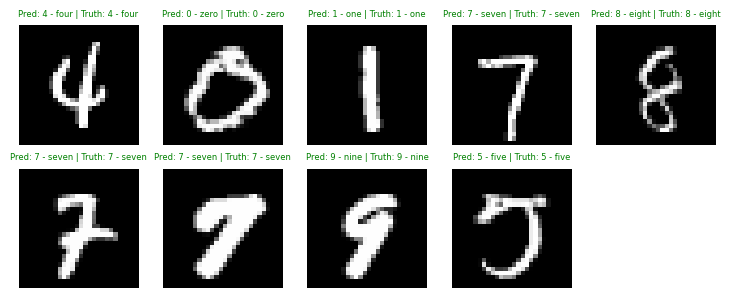

In [61]:
# plot predictions
plt.figure(figsize=(9,9))
nrows = 5
ncols=5
for i,sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows,ncols,i+1)
  # Plot the target image
  plt.imshow(sample.squeeze(),cmap="gray")
  #find the prediction label in text
  pred_label = class_names[pred_classes[i]]
  #get the truth table(in text form)
  truth_label =class_names[test_labels[i]]
  #create a title for the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  #check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text,fontsize=6,c="g")
  else:
    plt.title(title_text,fontsize=6,c="r")

  plt.axis(False)

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [62]:
torch.manual_seed(42)
model_ex.eval()
y_preds = []
with torch.inference_mode():
  for X,y in test_dataloader:
    X,y=X.to(device),y.to(device)
    y_logit=model_ex(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
    y_preds.append(y_pred)

y_pred_tensor =torch.cat(y_preds)
y_pred_tensor

tensor([7, 2, 1,  ..., 4, 5, 6], device='cuda:0')

In [63]:
len(y_pred_tensor)

10000

In [64]:
# from torch import torchmetrices , mlxtend
! pip install torchmetrics mlxtend


In [65]:
import torchmetrics , mlxtend

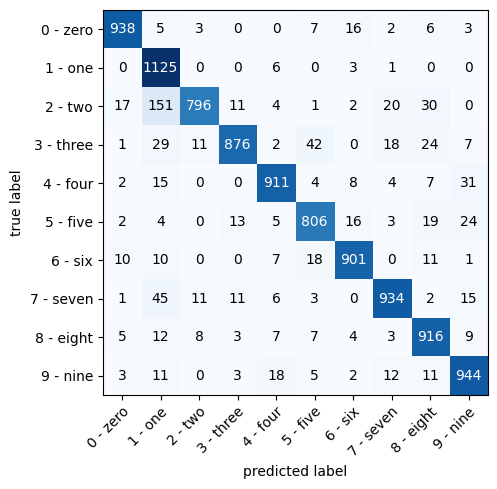

In [70]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
concat = ConfusionMatrix(task="multiclass", num_classes = len(class_names)).to(device)
confusion_matrix = concat(preds=y_pred_tensor.to(device),target=test_data.targets.to(device))
confusion_matrix
fig,ax = plot_confusion_matrix(conf_mat=confusion_matrix.cpu().numpy(),
                               class_names=class_names,
                               figsize=(10,5))

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [71]:
random_tenor = torch.randn(size=(1,3,64,64))
random_tenor.shape

torch.Size([1, 3, 64, 64])

In [72]:
result = nn.Conv2d(in_channels=3,out_channels=1,kernel_size=3,stride=2,padding=1
                   )
result(random_tenor).shape

torch.Size([1, 1, 32, 32])

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [75]:
train_data_fashion = torchvision.datasets.FashionMNIST(
    root="'",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform = None
)
test_data_fashion = torchvision.datasets.FashionMNIST(
    root="'",
    train=False,
    download =True,
    transform =ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.00MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


In [76]:
len(train_data_fashion),len(test_data_fashion)

(60000, 10000)

In [77]:
class_name = train_data_fashion.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [78]:
model_fashion=CNNModel(input_channel=1,hidden_units=10,output_shape=len(class_name)).to(device)
model_fashion

CNNModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

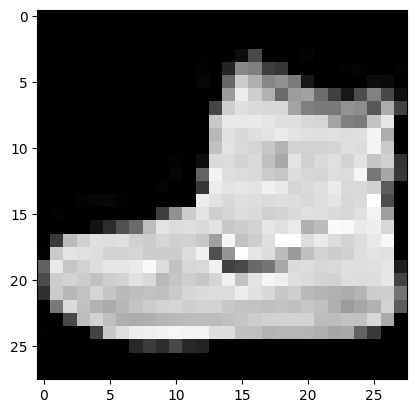

In [79]:
plt.imshow(train_data_fashion[0][0].squeeze(),cmap="gray")

In [80]:
training_dataloader_fashion =DataLoader(dataset=train_data_fashion,
                                        batch_size=32,
                                        shuffle=True)
testing_dataloader_fashion = DataLoader(dataset = test_data_fashion,
                                        batch_size=32,
                                        shuffle=True)
training_dataloader_fashion,testing_dataloader_fashion

(<torch.utils.data.dataloader.DataLoader at 0x782103225450>,
 <torch.utils.data.dataloader.DataLoader at 0x78210324d810>)

In [82]:
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.SGD(params=model_fashion.parameters(),lr=0.1)

In [83]:
torch.manual_seed(42)

epochs =3
for epoch in range (epochs):
  print(f"Epoch:{epoch}\n-------")
  train_step(model=model_fashion,
             dataloader=training_dataloader_fashion,
             loss_fn=loss_fn_1,
             optimizer=optimizer_1,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_fashion,
            dataloader=testing_dataloader_fashion,
            loss_fn=loss_fn_1,
            accuracy_fn=accuracy_fn,
            device=device)


Epoch:0
-------
Train loss:0.55610 | Train accuracy :80.048%
test loss:0.37482 | test acc :86.651%
Epoch:1
-------
Train loss:0.33724 | Train accuracy :87.798%
test loss:0.35775 | test acc :86.971%
Epoch:2
-------
Train loss:0.30567 | Train accuracy :89.098%
test loss:0.30426 | test acc :88.698%


In [89]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_fashion_result=eval_step(model=model_fashion,
                              dataloader=testing_dataloader_fashion,
                              loss_fn=loss_fn_1,
                              accuracy_fn=accuracy_fn,
                              device=device)
model_fashion_result

loss:0.01407 | acc:9.844%
